In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import plotly.express as px

# !pip install missingno
import missingno as msno

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

In [2]:
train_df = pd.read_csv('../data/train_clean.csv')
test_df = pd.read_csv('../data/test_clean.csv')

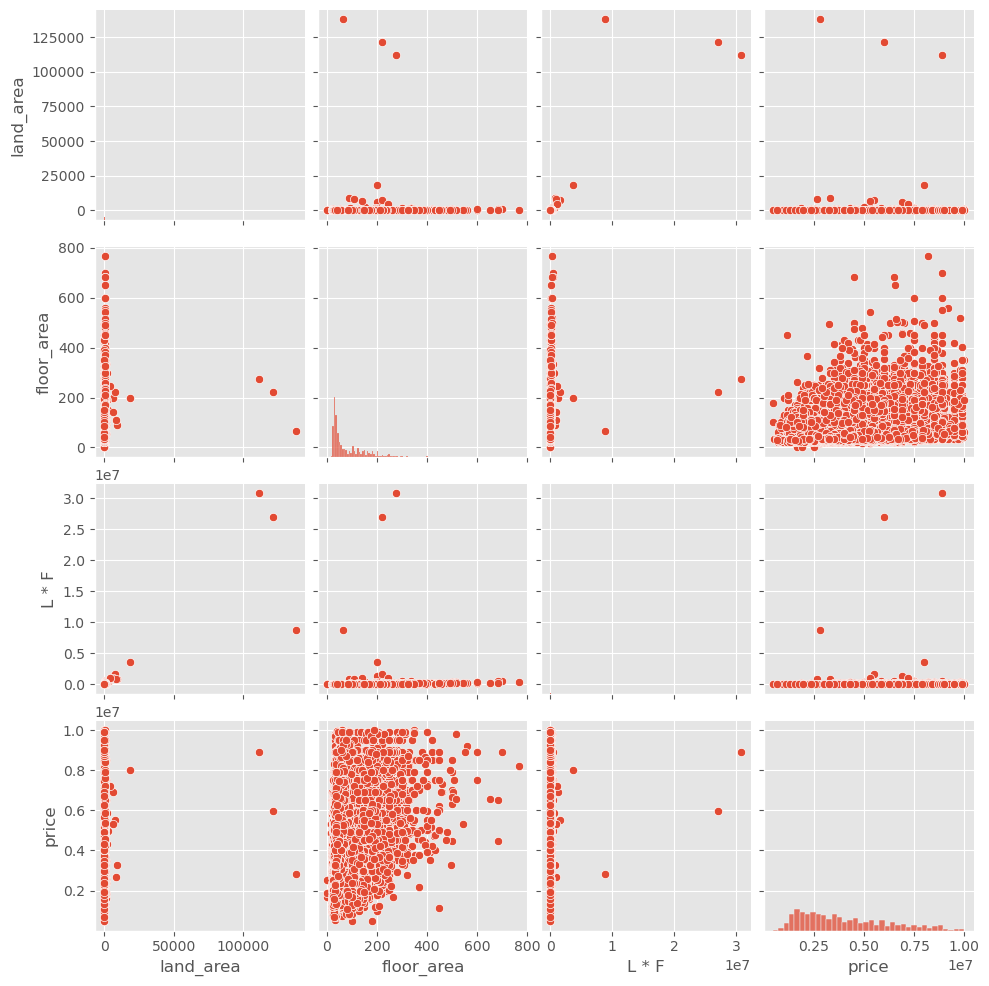

In [3]:
train_df['L * F'] = train_df['land_area'] * train_df['floor_area']

features = [ 'land_area', 'floor_area', 'L * F', 'price'
                            ]

sns.pairplot(train_df[features]);

In [4]:
train_df.head()

,id,province,district,property_type,bedrooms,baths,floor_area,floor_level,land_area,latitude,...,year_built,facilities,price,is_train,minimum_station_distance,has_security,has_pool,has_sports,has_parking,L * F
0,8448321,Bangkok,Watthana,Condo,2.0,2.0,66,10.0,0.0,13.721944,...,2011,"['Car Park', 'Community Garden', 'CCTV', 'Fitn...",8500000.0,1,270,1,1,1,1,0.0
1,10936325,Bangkok,Watthana,Condo,1.0,1.0,49,8.0,0.0,13.741904,...,2012,"['CCTV', 'Fitness corner', '24 hours security'...",5900000.0,1,720,1,1,1,0,0.0
2,10927931,Bangkok,Khlong Toei,Condo,1.0,1.0,34,4.0,0.0,13.725395,...,2017,"['Car Park', 'Clubhouse', 'Community Garden', ...",6290000.0,1,650,1,1,1,1,0.0
3,11004792,Nonthaburi,Bang Kruai,Detached House,3.0,3.0,170,0.0,248.0,13.821687,...,0,"['Covered car park', 'Playground', '24 hours s...",8900000.0,1,0,1,1,0,1,42160.0
4,10757452,Nonthaburi,Mueang Nonthaburi,Townhouse,3.0,2.0,120,0.0,72.0,13.865849,...,0,"['Covered car park', '24 hours security']",2390000.0,1,10,1,0,0,1,8640.0


In [5]:
train_df.columns

Index(['id', 'province', 'district', 'property_type', 'bedrooms', 'baths',
       'floor_area', 'floor_level', 'land_area', 'latitude', 'longitude',
       'nearby_stations', 'nearby_station_distance', 'nearby_bus_stops',
       'nearby_supermarkets', 'nearby_shops', 'year_built', 'facilities',
       'price', 'is_train', 'minimum_station_distance', 'has_security',
       'has_pool', 'has_sports', 'has_parking', 'L * F'],
      dtype='object')

In [22]:
# Prepare your data
features = ['province', 'property_type', 'district', 'bedrooms', 'baths', 'floor_area', 'floor_level'
                             , 'land_area','nearby_stations','minimum_station_distance','has_security'
                             ,'has_pool', 'has_sports', 'has_parking'
                            ]

X = pd.get_dummies(train_df[features], 
                   columns=['province', 'property_type', 'district'], drop_first=True)
y = train_df['price']

# Split the data
X_train, X_dev, y_train, y_dev = train_test_split(X, y, train_size=0.8, random_state=42)

# Create and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on development set
y_pred = model.predict(X_dev)

# Evaluate the model
mse = mean_squared_error(y_dev, y_pred)
rmse = np.sqrt(mean_squared_error(y_dev, y_pred))
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 1625941149879.1553
Root Mean Squared Error: 1275123.9743174603


In [34]:
# Prepare your features and target variable for the test set
X_test = pd.get_dummies(test_df[features], 
                        columns=['province', 'property_type', 'district'], drop_first=True)

# Ensure the test set has the same columns as the training set
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Predict on the test set using the trained model
y_test_pred = model.predict(X_test)

# Create a DataFrame to hold the predictions
test_df['price'] = y_test_pred

# View the predictions
print(test_df['price'])


0       5.658390e+06
1       5.718004e+06
2       4.972504e+06
3       5.322781e+06
4       2.954355e+06
            ...     
2495    6.212944e+06
2496    6.716653e+06
2497    2.613422e+06
2498    1.542231e+06
2499    2.881727e+06
Name: price, Length: 2500, dtype: float64


In [30]:
y_test_pred

array([5658390.35334133, 5718003.80189665, 4972504.40909719, ...,
       2613422.0789547 , 1542230.51196303, 2881727.37159636])

In [38]:
#test_df['price'] = pred_test
test_df[['id','price']].to_csv('../data/submission.csv', index=False)